In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name):
    """Сохранить текущую фигуру в reports/figures"""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=140, bbox_inches="tight")

## 1. Загрузка и общая структура данных

In [2]:
raw = du.load_raw()
print(f"Размер таблицы: {raw.shape[0]} объектов x {raw.shape[1]} колонок")
print(f"Признаков (без таргетов): {raw.shape[1] - 3}")
print(f"\nТипы данных:\n{raw.dtypes.value_counts().to_string()}")
print(f"\nПолных дубликатов строк: {raw.duplicated().sum()}")
print(f"Дубликатов по признакам (без таргетов): "
      f"{raw.drop(columns=list(du.TARGETS)).duplicated().sum()}")

Размер таблицы: 1001 объектов x 213 колонок
Признаков (без таргетов): 210

Типы данных:
float64    107
int64      106

Полных дубликатов строк: 32
Дубликатов по признакам (без таргетов): 197


In [3]:
missing = raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Колонок с пропусками: {len(missing)}; всего пропущенных значений: {missing.sum()}")
display(missing.to_frame("n_missing").assign(
    share=lambda d: (d.n_missing / len(raw) * 100).round(2)))

rows_with_na = raw.index[raw.isna().any(axis=1)]
print(f"\nСтрок с хотя бы одним пропуском: {len(rows_with_na)} -> {list(rows_with_na)}")

Колонок с пропусками: 12; всего пропущенных значений: 36


,n_missing,share
MaxPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxAbsPartialCharge,3,0.3
MinAbsPartialCharge,3,0.3
BCUT2D_MWHI,3,0.3
BCUT2D_MWLOW,3,0.3
BCUT2D_CHGHI,3,0.3
BCUT2D_CHGLO,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_LOGPLOW,3,0.3



Строк с хотя бы одним пропуском: 3 -> [78, 79, 80]


**Наблюдение.** Пропуски в 12 колонках и затрагивают 3 объекта
Это дескрипторы `MaxPartialCharge`, `MinPartialCharge` и семейство `BCUT2D_*`  все они
рассчитываются RDKit через частичные заряды, которые не определены для
пары типов атомов
Удалять 3 объекта из 1000 нерационально и чтобы не допустить утечки статистик обучающей выборки в тестовую будем используем медианную импутацию внутри
пайплаина

## 2. Целевые переменные

In [4]:
targets = raw[list(du.TARGETS)]
desc = targets.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["skew"] = targets.skew()
desc["kurtosis"] = targets.kurtosis()
desc["CV"] = targets.std() / targets.mean()
display(desc.round(3))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis,CV
"IC50, mM",1001.0,222.805,402.170,0.004,0.044,1.400,12.515,46.585,224.976,1076.691,1440.493,4128.529,3.675,22.450,1.805
"CC50, mM",1001.0,589.111,642.868,0.701,0.999,9.789,99.999,411.039,894.089,1936.356,3284.331,4538.976,1.973,5.679,1.091
SI,1001.0,72.509,684.483,0.011,0.134,0.988,1.433,3.846,16.567,113.636,807.726,15620.600,18.013,361.417,9.440


### 2.1. Проверка соотношения SI = CC50 / IC50

In [ ]:
si_calc = raw[du.TARGET_CC50] / raw[du.TARGET_IC50]
rel_err = ((si_calc - raw[du.TARGET_SI]).abs() / raw[du.TARGET_SI])
print(f"Максимальная относительная ошибка: {rel_err.max():.3e}")
print(f"Коэффициент корреляции Пирсона: {np.corrcoef(si_calc, raw[du.TARGET_SI])[0, 1]:.12f}")
print(f"Число расхождений > 1e-6: {(rel_err > 1e-6).sum()}")
print("\nВывод: SI = CC50 / IC50 выполняется с машинной точностью для всех 1001 объекта")

Максимальная относительная ошибка: 8.463e-16
Коэффициент корреляции Пирсона: 1.000000000000
Число расхождений > 1e-6: 0

Вывод: SI = CC50 / IC50 выполняется с машинной точностью для всех 1001 объекта.


### 2.2. Распределения таргетов и необходимость логарифмирования

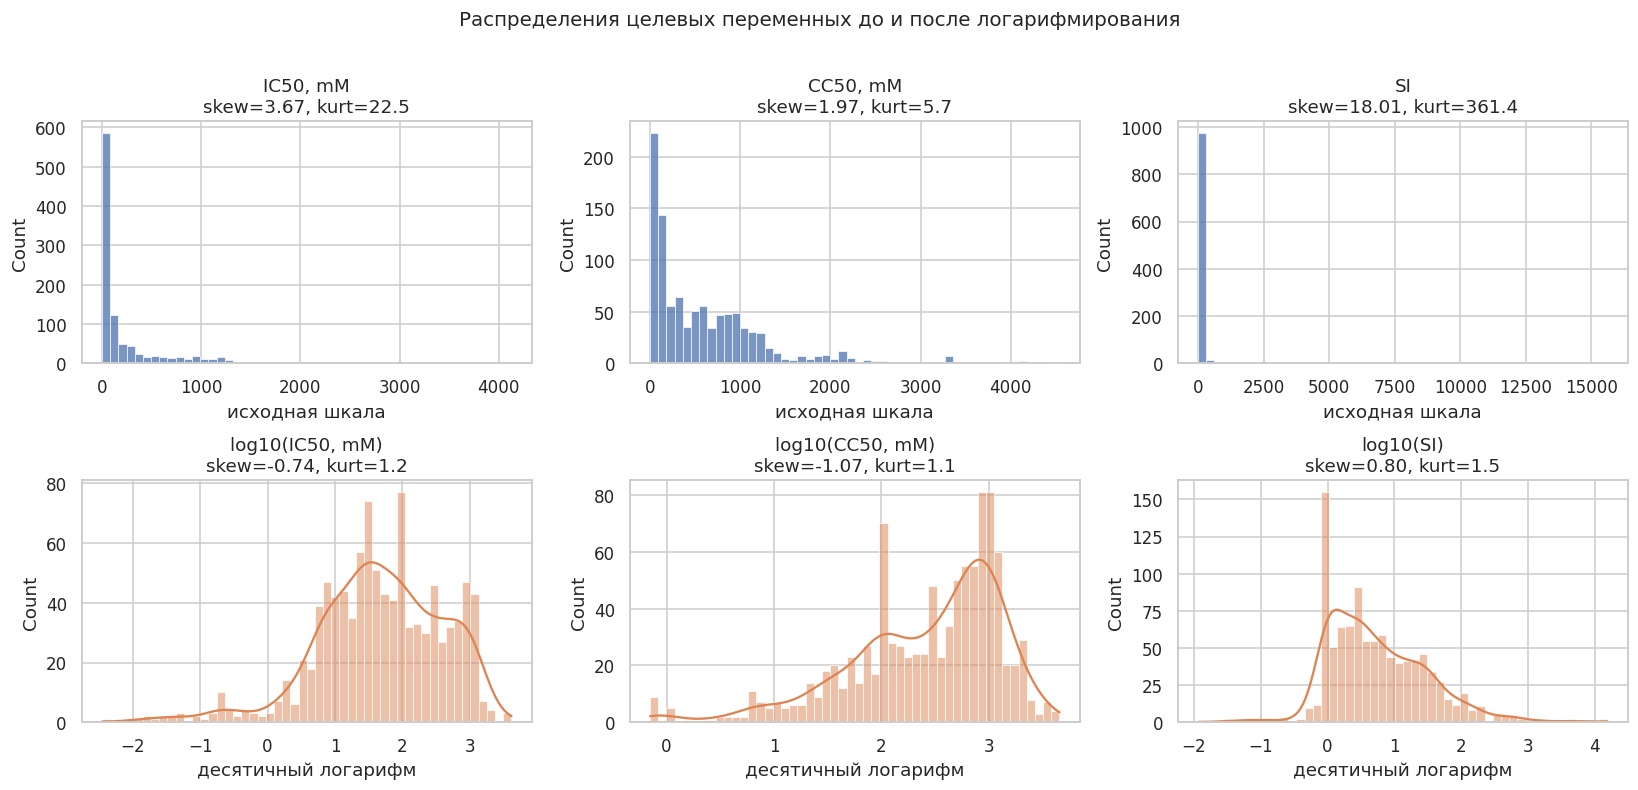

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for j, col in enumerate(du.TARGETS):
    sns.histplot(targets[col], bins=50, ax=axes[0, j], color="#4C72B0")
    axes[0, j].set_title(f"{col}\nskew={targets[col].skew():.2f}, "
                         f"kurt={targets[col].kurtosis():.1f}")
    axes[0, j].set_xlabel("исходная шкала")

    logged = np.log10(targets[col])
    sns.histplot(logged, bins=50, ax=axes[1, j], color="#DD8452", kde=True)
    axes[1, j].set_title(f"log10({col})\nskew={logged.skew():.2f}, "
                         f"kurt={logged.kurtosis():.1f}")
    axes[1, j].set_xlabel("десятичный логарифм")
fig.suptitle("Распределения целевых переменных до и после логарифмирования",
             fontsize=13, y=1.02)
save_fig("01_target_distributions")
plt.show()

In [ ]:
rows = []
for col in du.TARGETS:
    raw_v, log_v = targets[col], np.log10(targets[col])
    rows.append({
        "target": col,
        "skew_raw": raw_v.skew(), "skew_log": log_v.skew(),
        "kurt_raw": raw_v.kurtosis(), "kurt_log": log_v.kurtosis(),
        "shapiro_p_raw": stats.shapiro(raw_v)[1],
        "shapiro_p_log": stats.shapiro(log_v)[1],
        "dagostino_p_log": stats.normaltest(log_v)[1],
        "ratio_max_min": raw_v.max() / raw_v.min(),
    })
display(pd.DataFrame(rows).set_index("target").round(4))

,skew_raw,skew_log,kurt_raw,kurt_log,shapiro_p_raw,shapiro_p_log,dagostino_p_log,ratio_max_min
target,,,,,,,,
"IC50, mM",3.6749,-0.7391,22.4503,1.1894,0.0,0.0,0.0,1.173980e+06
"CC50, mM",1.9733,-1.0734,5.6794,1.1151,0.0,0.0,0.0,6.476776e+03
SI,18.0132,0.7965,361.4167,1.4779,0.0,0.0,0.0,1.359582e+06


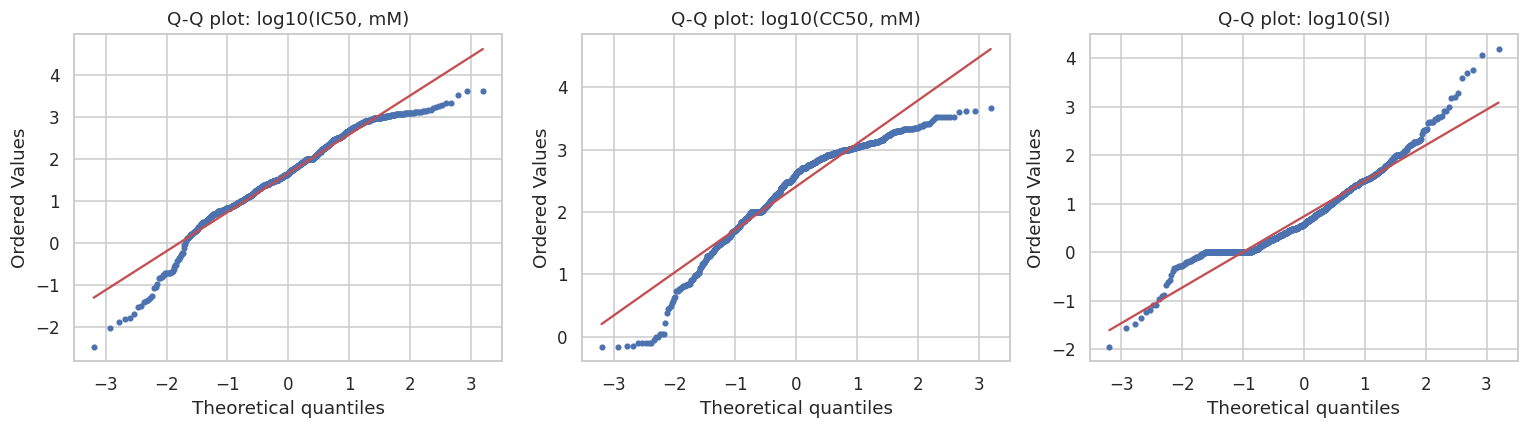

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, du.TARGETS):
    stats.probplot(np.log10(targets[col]), dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: log10({col})")
    ax.get_lines()[0].set_markersize(3)
save_fig("02_qq_log_targets")
plt.show()

**Выводы по распределениям.**

1. асимметрия 3.7, 2.0 и 18.0 ,если обучать регрессию в сыром виде,то модель просто перестанет видеть основную массу данных
2. После десятичного логарифма картина меняется: асимметрия падает до −0.74 / −1.07 / 0.80
у IC50 и CC50 асимметрия уходит в минус - появляется левый хвост из небольшой группы сверхактивных соединений
3. Тесты Шапиро–Уилка всё равно бракуют нормальность даже после логарифмирования,
глядя на Q-Q графики, видно: основная масса точек ложится на прямую, а расхождения торчат только на хвостах

все регрессионные модели обучаем в log10, это выравнивает дисперсию , превращает MSE в адекватную метрику.
Итоговые результаты откатываем обратно в исходную шкалу

### 2.3. Совместное распределение таргетов

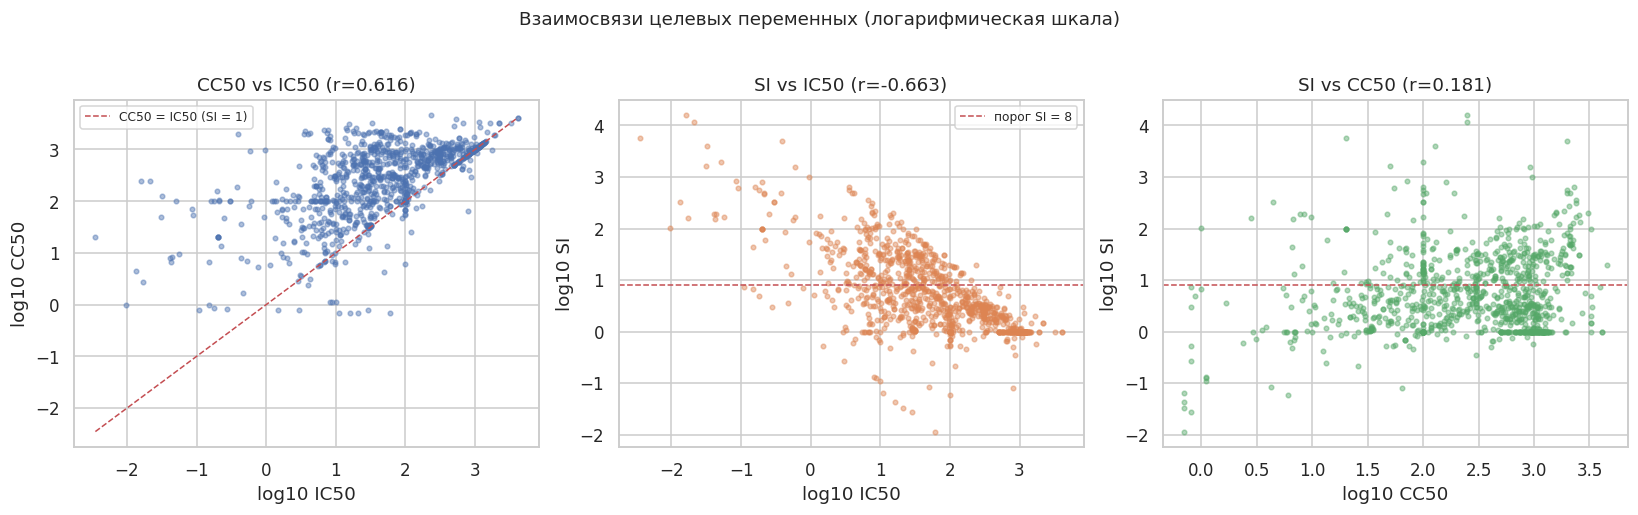

Корреляционная матрица логарифмов таргетов (Пирсон):


,log_IC50,log_CC50,log_SI
log_IC50,1.000,0.616,-0.663
log_CC50,0.616,1.000,0.181
log_SI,-0.663,0.181,1.000



Spearman:


,log_IC50,log_CC50,log_SI
log_IC50,1.000,0.621,-0.643
log_CC50,0.621,1.000,0.100
log_SI,-0.643,0.100,1.000


In [9]:
log_t = np.log10(targets)
log_t.columns = ["log_IC50", "log_CC50", "log_SI"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(log_t.log_IC50, log_t.log_CC50, s=9, alpha=.45, c="#4C72B0")
axes[0].set(xlabel="log10 IC50", ylabel="log10 CC50",
            title=f"CC50 vs IC50 (r={log_t.log_IC50.corr(log_t.log_CC50):.3f})")
lims = [log_t.log_IC50.min(), log_t.log_IC50.max()]
axes[0].plot(lims, lims, "r--", lw=1, label="CC50 = IC50 (SI = 1)")
axes[0].legend(fontsize=8)

axes[1].scatter(log_t.log_IC50, log_t.log_SI, s=9, alpha=.45, c="#DD8452")
axes[1].set(xlabel="log10 IC50", ylabel="log10 SI",
            title=f"SI vs IC50 (r={log_t.log_IC50.corr(log_t.log_SI):.3f})")
axes[1].axhline(np.log10(8), color="r", ls="--", lw=1, label="порог SI = 8")
axes[1].legend(fontsize=8)

axes[2].scatter(log_t.log_CC50, log_t.log_SI, s=9, alpha=.45, c="#55A868")
axes[2].set(xlabel="log10 CC50", ylabel="log10 SI",
            title=f"SI vs CC50 (r={log_t.log_CC50.corr(log_t.log_SI):.3f})")
axes[2].axhline(np.log10(8), color="r", ls="--", lw=1)
fig.suptitle("Взаимосвязи целевых переменных (логарифмическая шкала)", y=1.03)
save_fig("03_targets_pairwise")
plt.show()

print("Корреляционная матрица логарифмов таргетов (Пирсон):")
display(log_t.corr().round(3))
print("\nSpearman:")
display(log_t.corr(method="spearman").round(3))

## 3. Анализ выбросов

In [10]:
def outlier_report(series, name, log_scale=False):
    """Сводка по выбросам методами IQR (1.5 и 3.0) и робастного z-score."""
    v = np.log10(series) if log_scale else series
    q1, q3 = v.quantile([.25, .75])
    iqr = q3 - q1
    mad = stats.median_abs_deviation(v, scale="normal")
    rz = (v - v.median()).abs() / mad
    return {
        "переменная": name,
        "IQR x1.5": int(((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).sum()),
        "IQR x3.0": int(((v < q1 - 3 * iqr) | (v > q3 + 3 * iqr)).sum()),
        "|robust z| > 3": int((rz > 3).sum()),
        "|robust z| > 5": int((rz > 5).sum()),
    }


rep = [outlier_report(targets[c], c, False) for c in du.TARGETS]
rep += [outlier_report(targets[c], f"log10({c})", True) for c in du.TARGETS]
display(pd.DataFrame(rep).set_index("переменная"))

,IQR x1.5,IQR x3.0,|robust z| > 3,|robust z| > 5
переменная,,,,
"IC50, mM",147,89,247,186
"CC50, mM",39,11,49,12
SI,125,87,251,192
"log10(IC50, mM)",19,0,13,0
"log10(CC50, mM)",21,0,24,0
log10(SI),14,0,10,0


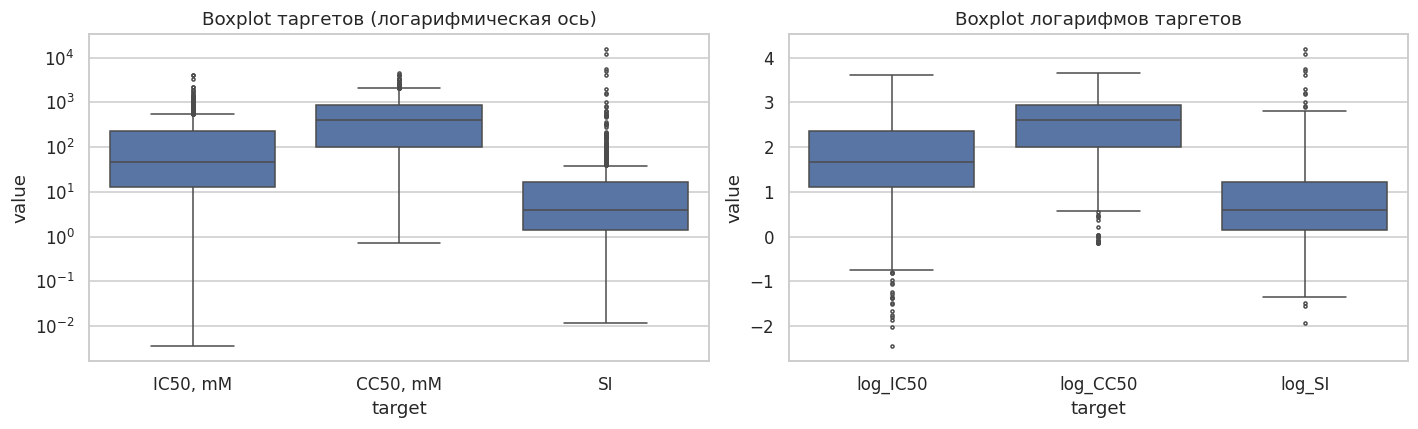

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=targets.melt(var_name="target"), x="target", y="value",
            ax=axes[0], showfliers=True, fliersize=2)
axes[0].set_yscale("log")
axes[0].set_title("Boxplot таргетов (логарифмическая ось)")

sns.boxplot(data=log_t.melt(var_name="target"), x="target", y="value",
            ax=axes[1], showfliers=True, fliersize=2)
axes[1].set_title("Boxplot логарифмов таргетов")
save_fig("04_target_boxplots")
plt.show()

In [12]:
extreme = targets.assign(log_SI=log_t.log_SI).nlargest(10, "SI")
print("10 объектов с максимальным SI:")
display(extreme.round(3))
print("\n10 объектов с минимальным SI:")
display(targets.nsmallest(10, "SI").round(4))

10 объектов с максимальным SI:


,"IC50, mM","CC50, mM",SI,log_SI
799,0.016,249.999,15620.600,4.194
773,0.021,250.002,11848.333,4.074
771,0.004,19.999,5687.000,3.755
110,0.393,1965.440,5000.000,3.699
796,0.032,128.090,4001.700,3.602
794,0.051,99.999,1952.562,3.291
823,0.031,50.001,1618.889,3.209
180,0.590,921.129,1562.500,3.194
795,0.960,960.267,1000.000,3.000
897,0.086,71.201,828.935,2.919



10 объектов с минимальным SI:


,"IC50, mM","CC50, mM",SI
755,60.9967,0.7008,0.0115
788,29.0001,0.8002,0.0276
791,21.0010,0.7010,0.0334
790,16.0013,0.7010,0.0438
888,99.9994,6.0003,0.0600
756,11.0014,0.7008,0.0637
268,803.3688,64.8497,0.0807
874,49.9996,4.1988,0.0840
803,9.9996,1.1015,0.1102
804,8.7016,1.1015,0.1266


**вывод** логарифмирование решает проблему выбросов полностью, удалять 10% объектов нельзя из-за важности соединений.
Остаются единичные экстремумы (SI до 15620 при медиане 3.8)  они могут влиять на модель

In [ ]:
top_si = targets.nlargest(20, "SI")
print("У 20 объектов с максимальным SI:")
print(f"  медиана IC50 = {top_si[du.TARGET_IC50].median():.4f} "
      f"(по всей выборке {targets[du.TARGET_IC50].median():.2f})")
print(f"  медиана CC50 = {top_si[du.TARGET_CC50].median():.1f} "
      f"(по всей выборке {targets[du.TARGET_CC50].median():.1f})")
print("\nВывод: экстремальный SI порождается именно аномально малым IC50, "
      "а не выдающейся безопасностью — это реально сверхактивные соединения")

q = targets[du.TARGET_SI].quantile([.99, .995])
print(f"\n99-й перцентиль SI  = {q.iloc[0]:.1f}")
print(f"99.5-й перцентиль SI = {q.iloc[1]:.1f}")
print(f"Объектов выше 99.5-го перцентиля: {(targets[du.TARGET_SI] > q.iloc[1]).sum()}")

У 20 объектов с максимальным SI:
  медиана IC50 = 0.1889 (по всей выборке 46.59)
  медиана CC50 = 175.1 (по всей выборке 411.0)

Вывод: экстремальный SI порождается именно аномально малым IC50, а не выдающейся безопасностью — это реально сверхактивные соединения.

99-й перцентиль SI  = 807.7
99.5-й перцентиль SI = 1952.6
Объектов выше 99.5-го перцентиля: 5


## 4. Скрытые артефакты данных

Гистограмма log10(SI) содержит аномально высокий пик ровно в нуле, а гистограмма
log10(CC50) пик в точке 2

### 4.1. Цензурированные измерения: SI ровно равен 1

In [14]:
exact_one = np.isclose(raw[du.TARGET_SI], 1.0, rtol=1e-9)
print(f"Объектов с SI ровно 1.000: {exact_one.sum()} ({exact_one.mean():.1%} выборки)")
print(f"У всех у них IC50 == CC50 с точностью до 1e-9: "
      f"{np.isclose(raw.loc[exact_one, du.TARGET_IC50], raw.loc[exact_one, du.TARGET_CC50]).all()}")
print("\nСравнение групп по IC50:")
display(pd.DataFrame({
    "SI = 1 (n=%d)" % exact_one.sum(): raw.loc[exact_one, list(du.TARGETS)].describe(),
    }).round(2) if False else raw.assign(
        группа=np.where(exact_one, "SI ровно 1", "остальные")
    ).groupby("группа")[list(du.TARGETS)].agg(["median", "mean"]).round(2))

Объектов с SI ровно 1.000: 135 (13.5% выборки)
У всех у них IC50 == CC50 с точностью до 1e-9: True

Сравнение групп по IC50:


IC50, mM         CC50, mM            SI       
             median    mean   median   mean median   mean
группа                                                   
SI ровно 1   917.96  850.90   917.96  850.9   1.00   1.00
остальные     34.73  124.89   307.18  548.3   5.47  83.66

In [15]:
val_counts = raw[du.TARGET_SI].round(6).value_counts().head(6)
print("Самые частые значения SI:")
display(val_counts.to_frame("частота"))

print("\nСамые частые значения CC50 (округление до 3 знаков):")
display(raw[du.TARGET_CC50].round(3).value_counts().head(6).to_frame("частота"))

for col in (du.TARGET_IC50, du.TARGET_CC50):
    near_100 = ((raw[col] > 99.9) & (raw[col] < 100.1)).sum()
    print(f"{col}: значений в окрестности 100 -> {near_100}")

Самые частые значения SI:


,частота
SI,
1.000000,135
3.000000,10
2.307692,8
1.764706,7
1.195219,6
2.000000,5



Самые частые значения CC50 (округление до 3 знаков):


,частота
"CC50, mM",
100.000,17
99.999,14
100.001,6
99.997,6
3284.331,6
299.995,5


IC50, mM: значений в окрестности 100 -> 23
CC50, mM: значений в окрестности 100 -> 48


**решение** объекты сохраняем, но факт цензурирования фиксируем в
отчёте как основной источник неустранимой ошибки регрессии SI. В качестве
дополнительного эксперимента в ноутбуке регрессии SI обучу модель без цензурированной
подгруппы и сравню качество

### 4.2. Повторяющиеся молекулы и риск утечки данных

In [16]:
features_all = raw.drop(columns=list(du.TARGETS))
feature_key = features_all.fillna(-999).round(8).astype(str).agg("|".join, axis=1)
group_id = pd.factorize(feature_key)[0]
group_sizes = pd.Series(group_id).value_counts()

print(f"Строк в таблице: {len(raw)}")
print(f"Уникальных наборов дескрипторов (молекул): {group_sizes.size}")
print(f"Строк, входящих в группы-повторы: {(group_sizes[group_sizes > 1]).sum()}")
print("\nРаспределение размеров групп:")
display(group_sizes.value_counts().sort_index().rename_axis(
    "объектов в группе").to_frame("число групп"))

Строк в таблице: 1001
Уникальных наборов дескрипторов (молекул): 804
Строк, входящих в группы-повторы: 301

Распределение размеров групп:


,число групп
объектов в группе,
1,700
2,78
3,13
4,6
5,1
8,1
10,1
11,1
12,1


In [17]:
dup_mask = pd.Series(group_id).map(group_sizes) > 1
dup_frame = raw[dup_mask.values].assign(gid=group_id[dup_mask.values])
identical = dup_frame.groupby("gid")[list(du.TARGETS)].nunique()
print("Доля групп, где таргеты полностью совпадают:")
display((identical == 1).mean().round(3).to_frame("доля групп"))

within = dup_frame.groupby("gid").apply(
    lambda d: np.log10(d[du.TARGET_IC50]).std())
print(f"\nМедианный внутригрупповой std log10(IC50): {within.median():.3f}")
print(f"Общий std log10(IC50) по выборке: {np.log10(raw[du.TARGET_IC50]).std():.3f}")
print(f"Доля дисперсии, приходящаяся на воспроизводимость эксперимента: "
      f"{(within.median() ** 2) / (np.log10(raw[du.TARGET_IC50]).std() ** 2):.1%}")

print("\nПример группы с одинаковыми дескрипторами и разными таргетами:")
biggest = group_sizes[group_sizes > 1].index[0]
display(raw[group_id == biggest][list(du.TARGETS)].round(3))

Доля групп, где таргеты полностью совпадают:


,доля групп
"IC50, mM",0.231
"CC50, mM",0.288
SI,0.173



Медианный внутригрупповой std log10(IC50): 0.299
Общий std log10(IC50) по выборке: 0.941
Доля дисперсии, приходящаяся на воспроизводимость эксперимента: 10.1%

Пример группы с одинаковыми дескрипторами и разными таргетами:


,"IC50, mM","CC50, mM",SI
802,7.502,100.000,13.330
803,10.000,1.102,0.110
804,8.702,1.102,0.127
805,8.202,1.102,0.134
806,10.999,100.000,9.092
807,10.000,250.003,25.001
808,98.276,1310.353,13.333
809,43.999,2130.007,48.410
810,29.999,2130.007,71.003
811,22.002,58.000,2.636


In [18]:
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
import lightgbm as lgb

X_leak, _ = du.clean_features(raw)
rows = []
for label, col in [("log IC50", du.TARGET_IC50), ("log CC50", du.TARGET_CC50),
                   ("log SI", du.TARGET_SI)]:
    target = np.log10(raw[col])
    model = lgb.LGBMRegressor(verbose=-1, n_estimators=300, learning_rate=0.05,
                              random_state=du.RANDOM_STATE)
    random_cv = cross_val_score(
        model, X_leak, target,
        cv=KFold(5, shuffle=True, random_state=du.RANDOM_STATE), scoring="r2").mean()
    group_cv = cross_val_score(
        model, X_leak, target, cv=GroupKFold(5), groups=group_id, scoring="r2").mean()
    rows.append({"таргет": label, "R2 при случайной CV": random_cv,
                 "R2 при групповой CV": group_cv,
                 "завышение": random_cv - group_cv})
display(pd.DataFrame(rows).set_index("таргет").round(3))

,R2 при случайной CV,R2 при групповой CV,завышение
таргет,,,
log IC50,0.423,0.394,0.028
log CC50,0.384,0.375,0.009
log SI,0.206,0.186,0.020


Эксперимент подтвердил утечку обычная кросс-валидация завышает R^2,
решил везде внедрить групповую кросс-валидацию где группой служит уникальный набор дескрипторов, так же тестовая выборка тоже режется по группам. Таким образом ни одна молекула не попадет одновременно в обучение и контроль 

## 5. Очистка признакового пространства

In [19]:
const_cols = du.constant_columns(features_all)
print(f"Константных признаков: {len(const_cols)}")
print(const_cols)

Константных признаков: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


In [20]:
tmp = features_all.drop(columns=const_cols)
dup_map = du.duplicated_columns(tmp)
print(f"Полностью дублирующих колонок: {len(dup_map)}")
display(pd.DataFrame(list(dup_map.items()), columns=["дубликат", "оригинал"]))

Полностью дублирующих колонок: 5


,дубликат,оригинал
0,MaxEStateIndex,MaxAbsEStateIndex
1,fr_COO2,fr_COO
2,fr_Nhpyrrole,fr_Ar_NH
3,fr_benzene,NumAromaticCarbocycles
4,fr_phenol_noOrthoHbond,fr_phenol


Найденные дубликаты содержательно объяснимы: `MaxEStateIndex` совпадает с
`MaxAbsEStateIndex`
`fr_COO2` = `fr_COO`, `fr_benzene` = `NumAromaticCarbocycles` - RDKit считает эти
фрагменты по эквивалентным SMARTS-шаблонам. Оставляем по одному представителю

In [21]:
tmp2 = tmp.drop(columns=list(dup_map))
share_top = tmp2.apply(lambda c: c.value_counts(normalize=True).max()).sort_values(
    ascending=False)
near_const = share_top[share_top > 0.995]
print(f"Почти константных признаков (>99.5% одинаковых значений): {len(near_const)}")
display(near_const.to_frame("доля модального значения").round(4).head(30))

Почти константных признаков (>99.5% одинаковых значений): 9


,доля модального значения
fr_Ar_COO,0.999
fr_tetrazole,0.999
fr_term_acetylene,0.999
fr_HOCCN,0.999
fr_aldehyde,0.997
fr_hdrzine,0.997
fr_guanido,0.996
fr_oxazole,0.996
fr_epoxide,0.996


In [22]:
X, clean_report = du.clean_features(raw)
print("Итог очистки:")
for key, cols in clean_report.items():
    print(f"  {key:15s}: удалено {len(cols)}")
print(f"\nОсталось признаков: {X.shape[1]} (было {features_all.shape[1]})")

Итог очистки:
  constant       : удалено 18
  duplicated     : удалено 5
  near_constant  : удалено 9
  collinear      : удалено 0

Осталось признаков: 178 (было 210)


### 5.1. Мультиколлинеарность

In [23]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
for thr in (0.99, 0.95, 0.90, 0.80):
    print(f"Пар признаков с |r| > {thr}: {(pairs > thr).sum()}")

print("\nТоп-15 наиболее коррелированных пар:")
display(pairs.head(15).to_frame("|r|").round(4))

Пар признаков с |r| > 0.99: 14
Пар признаков с |r| > 0.95: 84
Пар признаков с |r| > 0.9: 146
Пар признаков с |r| > 0.8: 227

Топ-15 наиболее коррелированных пар:


,,|r|
MolWt,ExactMolWt,1.0000
Chi1,HeavyAtomCount,0.9987
MolWt,HeavyAtomMolWt,0.9969
HeavyAtomMolWt,ExactMolWt,0.9968
Chi0,HeavyAtomCount,0.9960
NumValenceElectrons,Chi0,0.9948
LabuteASA,HeavyAtomCount,0.9943
Chi1,LabuteASA,0.9929
Chi0n,Chi0v,0.9928
Chi0,Chi1,0.9909


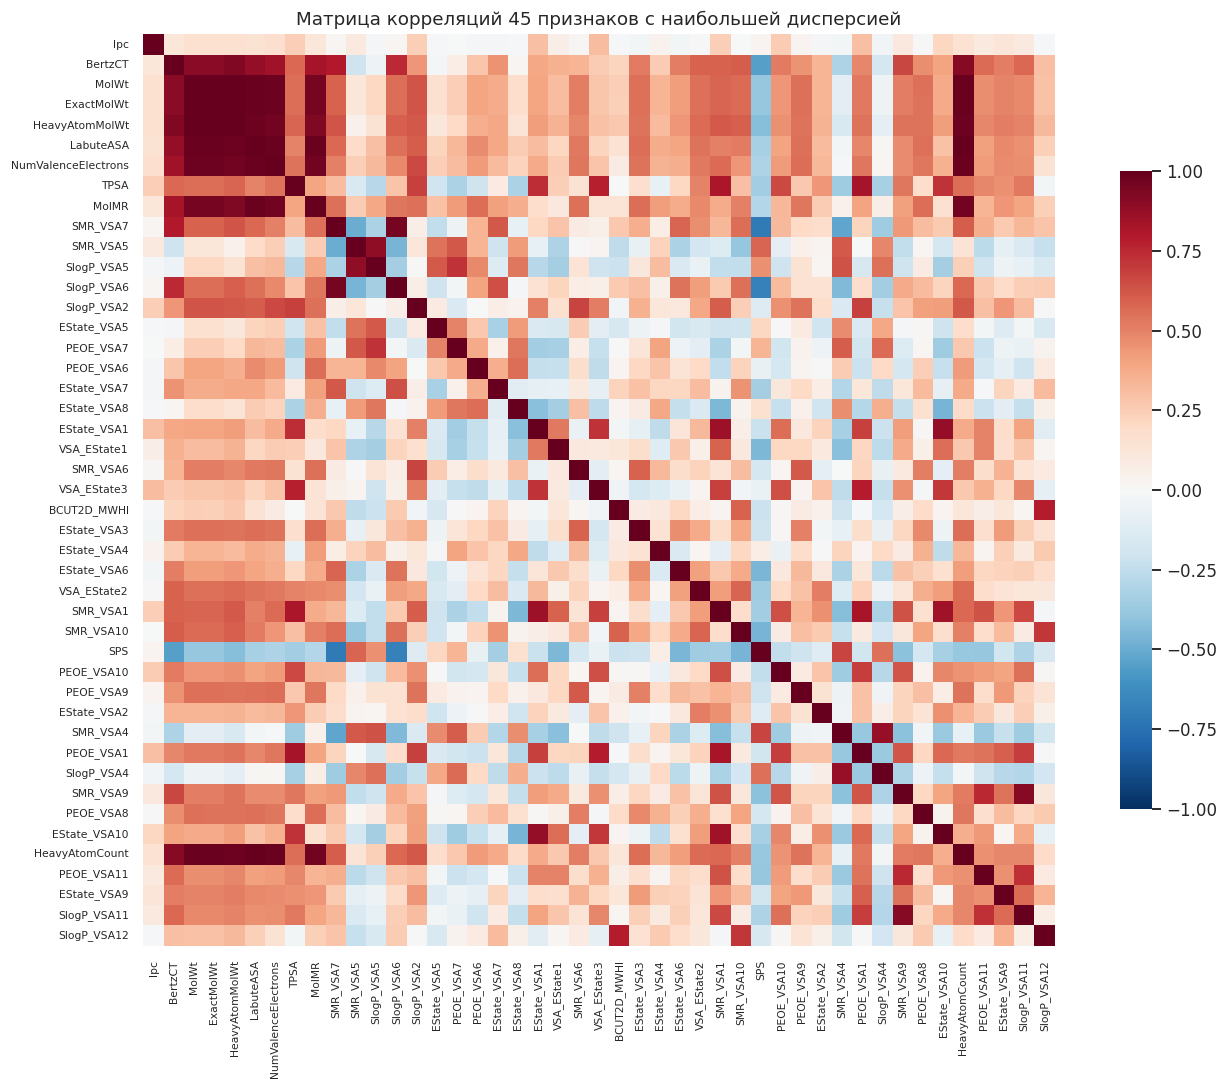

In [24]:
top_var = X.var().sort_values(ascending=False).head(45).index
plt.figure(figsize=(13, 10))
sns.heatmap(X[top_var].corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .7},
            xticklabels=True, yticklabels=True)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.title("Матрица корреляций 45 признаков с наибольшей дисперсией")
save_fig("05_corr_heatmap")
plt.show()

**итоговые мысли** много признаков с избыктом для RDKit это норм дескрипторы посути дублируют друг друга, описывая один и тот же параметр
Деревья и бустинг мультиколлинеарности не боятся, но важность признаков у них расползается по дубликатам,  рамках эксперимента сранвю две версии модели, где  все признаки против отфильтрованных по порогу корреляции 0.95

## 6. Связь признаков с целевыми переменными

In [25]:
log_targets = pd.DataFrame({
    "log_IC50": np.log10(raw[du.TARGET_IC50]),
    "log_CC50": np.log10(raw[du.TARGET_CC50]),
    "log_SI": np.log10(raw[du.TARGET_SI]),
})
X_imp = X.fillna(X.median())

spearman = pd.DataFrame({
    name: X_imp.apply(lambda c: stats.spearmanr(c, log_targets[name])[0])
    for name in log_targets.columns
})
pearson = pd.DataFrame({
    name: X_imp.corrwith(log_targets[name]) for name in log_targets.columns
})

print("Максимальная по модулю корреляция признака с таргетом:")
display(pd.DataFrame({
    "max |Spearman|": spearman.abs().max(),
    "max |Pearson|": pearson.abs().max(),
    "признаков с |Spearman| > 0.2": (spearman.abs() > 0.2).sum(),
    "признаков с |Spearman| > 0.15": (spearman.abs() > 0.15).sum(),
}).round(3))

Максимальная по модулю корреляция признака с таргетом:


,max |Spearman|,max |Pearson|,признаков с |Spearman| > 0.2,признаков с |Spearman| > 0.15
log_IC50,0.278,0.285,14,31
log_CC50,0.303,0.251,30,54
log_SI,0.216,0.199,3,26


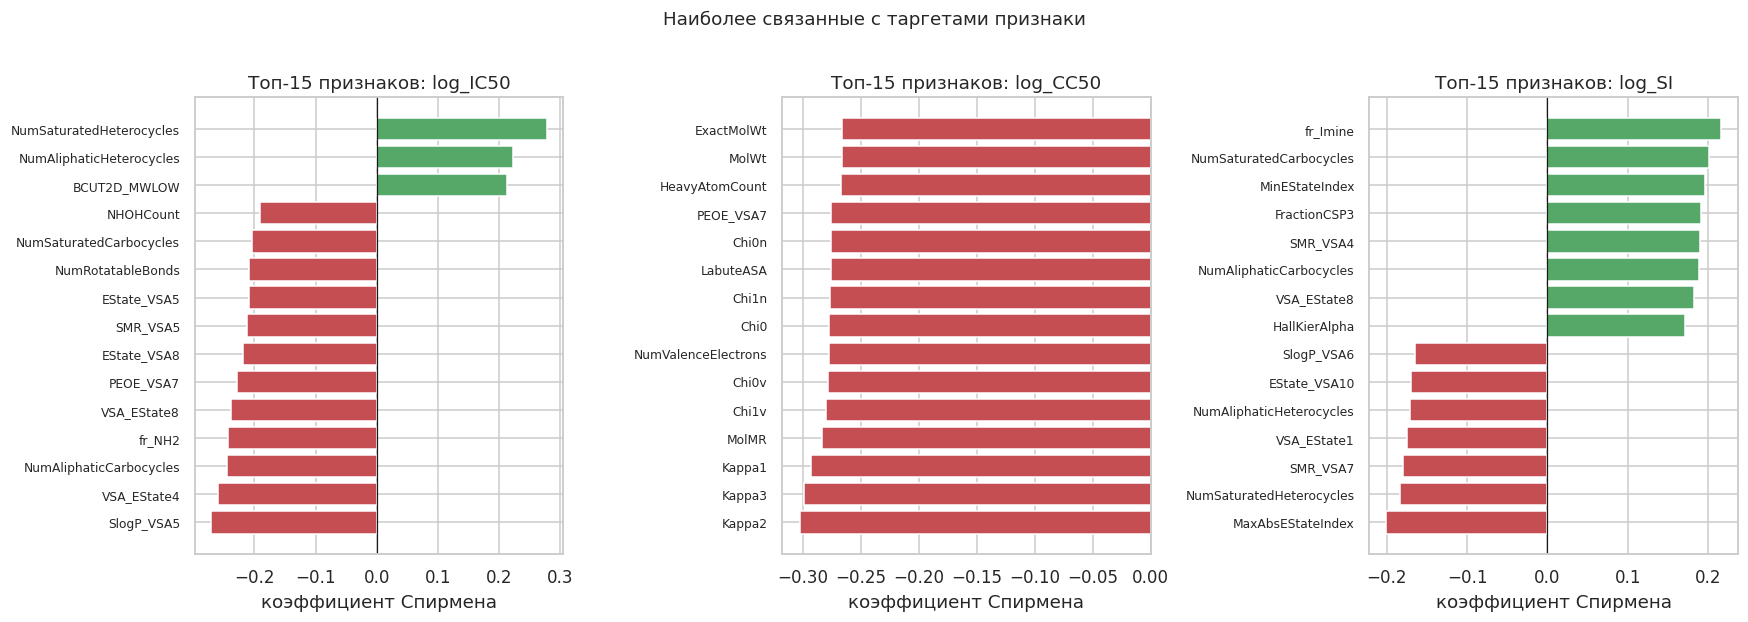

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, name in zip(axes, log_targets.columns):
    top = spearman[name].abs().sort_values(ascending=False).head(15).index
    vals = spearman.loc[top, name].sort_values()
    colors = ["#C44E52" if v < 0 else "#55A868" for v in vals]
    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"Топ-15 признаков: {name}")
    ax.set_xlabel("коэффициент Спирмена")
fig.suptitle("Наиболее связанные с таргетами признаки", y=1.02)
save_fig("06_top_features_spearman")
plt.show()

In [27]:
from sklearn.feature_selection import mutual_info_regression

mi = pd.DataFrame({
    name: mutual_info_regression(X_imp, log_targets[name],
                                 random_state=du.RANDOM_STATE)
    for name in log_targets.columns
}, index=X_imp.columns)

print("Взаимная информация (нелинейная связь), топ-12 по каждому таргету:")
for name in mi.columns:
    print(f"\n--- {name} ---")
    print(mi[name].sort_values(ascending=False).head(12).round(4).to_string())

Взаимная информация (нелинейная связь), топ-12 по каждому таргету:

--- log_IC50 ---
ExactMolWt             0.3142
MolWt                  0.3114
HeavyAtomMolWt         0.3011
MinAbsPartialCharge    0.3005
BCUT2D_CHGLO           0.2997
Kappa1                 0.2993
Chi0                   0.2927
VSA_EState8            0.2921
BCUT2D_LOGPHI          0.2870
AvgIpc                 0.2867
MaxPartialCharge       0.2840
BalabanJ               0.2822

--- log_CC50 ---
ExactMolWt             1.1802
MolWt                  1.1696
HeavyAtomMolWt         0.9632
LabuteASA              0.8332
Chi0                   0.8326
Chi1                   0.7892
NumValenceElectrons    0.7386
Kappa1                 0.7296
Chi0v                  0.7232
HeavyAtomCount         0.7130
MolMR                  0.6916
Chi0n                  0.6781

--- log_SI ---
BCUT2D_LOGPHI          0.2574
BCUT2D_CHGLO           0.2373
MaxAbsPartialCharge    0.2361
BCUT2D_LOGPLOW         0.2254
SMR_VSA4               0.2204
BCUT2D_MWLO

**Критически важный вывод.** Максимальная по модулю корреляция Спирмена
любого отдельного признака с таргетом составляет всего **0.28 для IC50, 0.30 для
CC50 и 0.22 для SI**. Ни один дескриптор не является сильным индивидуальным
предиктором.

линейного сигнала почти нет, вся надежда - на нелинейные взаимодействия признаков, ставка на ансамбли деревьев.
для IC50 лучше всего работают дескрипторы насыщенных гетероциклов и E-state индексы. Для CC50 - размер и ветвистость

## 7. Задачи классификации: пороги и баланс классов

In [28]:
y = du.build_targets(raw)
tasks = {
    "IC50 > медианы": "ic50_gt_median",
    "CC50 > медианы": "cc50_gt_median",
    "SI > медианы": "si_gt_median",
    "SI > 8": "si_gt_8",
}
info = pd.DataFrame([{
    "задача": label,
    "порог": {"ic50_gt_median": raw[du.TARGET_IC50].median(),
              "cc50_gt_median": raw[du.TARGET_CC50].median(),
              "si_gt_median": raw[du.TARGET_SI].median(),
              "si_gt_8": 8.0}[col],
    "класс 1, шт": int(y[col].sum()),
    "класс 0, шт": int((1 - y[col]).sum()),
    "доля класса 1": y[col].mean(),
} for label, col in tasks.items()]).set_index("задача")
display(info.round(3))

,порог,"класс 1, шт","класс 0, шт",доля класса 1
задача,,,,
IC50 > медианы,46.585,500,501,0.500
CC50 > медианы,411.039,499,502,0.499
SI > медианы,3.846,500,501,0.500
SI > 8,8.000,357,644,0.357


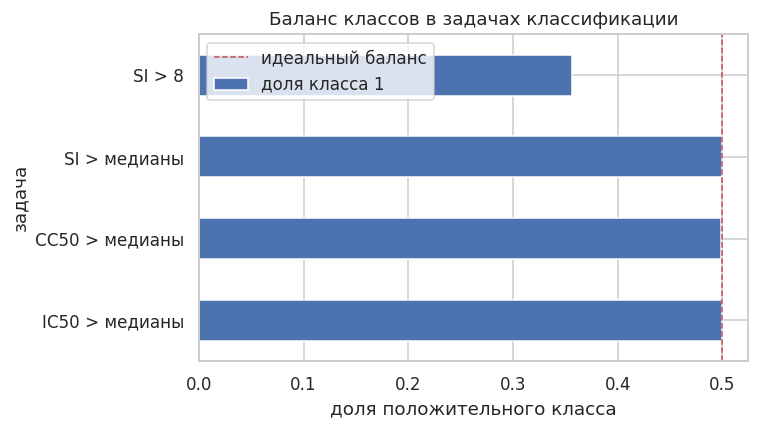

Согласованность 'SI > 8' и 'SI > медианы': 85.7% совпадений
Медиана SI = 3.85, порог 8 лежит в 64.2%-м перцентиле


In [29]:
plt.figure(figsize=(7, 4))
info["доля класса 1"].plot(kind="barh", color="#4C72B0")
plt.axvline(0.5, color="r", ls="--", lw=1, label="идеальный баланс")
plt.xlabel("доля положительного класса")
plt.title("Баланс классов в задачах классификации")
plt.legend()
save_fig("07_class_balance")
plt.show()

print(f"Согласованность 'SI > 8' и 'SI > медианы': "
      f"{(y.si_gt_8 == y.si_gt_median).mean():.1%} совпадений")
print(f"Медиана SI = {raw[du.TARGET_SI].median():.2f}, порог 8 лежит в "
      f"{(raw[du.TARGET_SI] < 8).mean():.1%}-м перцентиле")

**Выводы.**

Задачи с порогом по медиане идеально сбалансированы (50/50) — accuracy здесь адекватна, но основной метрикой оставляем ROC-AUC
Для SI > 8 дисбаланс умеренный: 35.7% положительного класса. Это не критично, но требует стратификации в кросс-валидации и акцента на метрики, чувствительные к меньшинству — F1 и PR-AUC. class_weight='balanced' включим в перебор гиперпараметров
Порог 8 — это 64-й перцентиль SI, то есть фактически «верхняя треть» по селективности, отсеим самых перспективных кандидатов
Классы SI > 8 и SI > медианы в основном перекрываются

## 8. Снижение размерности и структура выборки

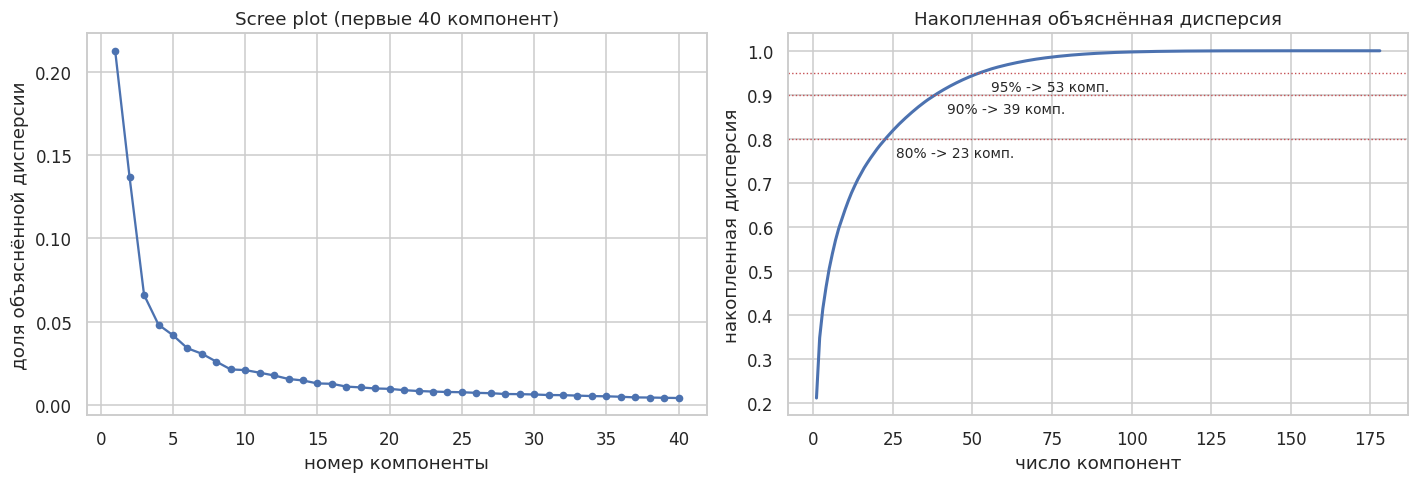

Компонент для 80% дисперсии: 23
Компонент для 95% дисперсии: 53


In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_imp)
pca = PCA(random_state=du.RANDOM_STATE).fit(X_scaled)
cum = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(1, 41), pca.explained_variance_ratio_[:40], "o-", ms=4)
axes[0].set(xlabel="номер компоненты", ylabel="доля объяснённой дисперсии",
            title="Scree plot (первые 40 компонент)")
axes[1].plot(range(1, len(cum) + 1), cum, lw=2)
for level in (0.8, 0.9, 0.95):
    n = int(np.searchsorted(cum, level) + 1)
    axes[1].axhline(level, color="r", ls=":", lw=.9)
    axes[1].annotate(f"{level:.0%} -> {n} комп.", (n, level),
                     textcoords="offset points", xytext=(6, -12), fontsize=9)
axes[1].set(xlabel="число компонент", ylabel="накопленная дисперсия",
            title="Накопленная объяснённая дисперсия")
save_fig("08_pca_variance")
plt.show()

print(f"Компонент для 80% дисперсии: {int(np.searchsorted(cum, .8) + 1)}")
print(f"Компонент для 95% дисперсии: {int(np.searchsorted(cum, .95) + 1)}")

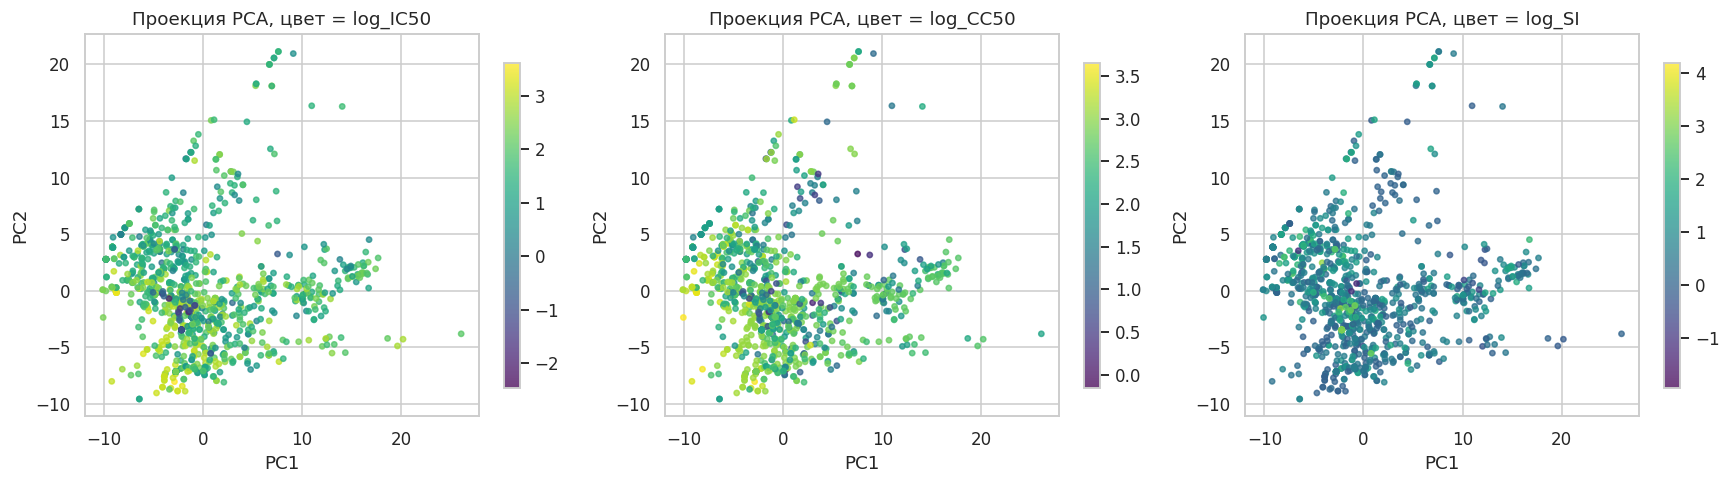

In [31]:
pcs = PCA(n_components=2, random_state=du.RANDOM_STATE).fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, series) in zip(axes, log_targets.items()):
    sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=series, cmap="viridis", s=12, alpha=.75)
    plt.colorbar(sc, ax=ax, shrink=.85)
    ax.set(xlabel="PC1", ylabel="PC2", title=f"Проекция PCA, цвет = {name}")
save_fig("09_pca_projection")
plt.show()

Всего шестая часть исходных признаков объясняет 95% дисперсии , цифры подтверждают избыточность. Но на проекциях PCA целевые переменные не образуют чётких кластеров: линии уровня активности не совпадают с главными компонентами. Это ещё один аргумент в пользу того, что связь дескрипторов с активностью  нелинейная и размазана по множеству признаков, а не лежит в паре главных направлений максимальной дисперси 

## 9. Структура признаков по группам

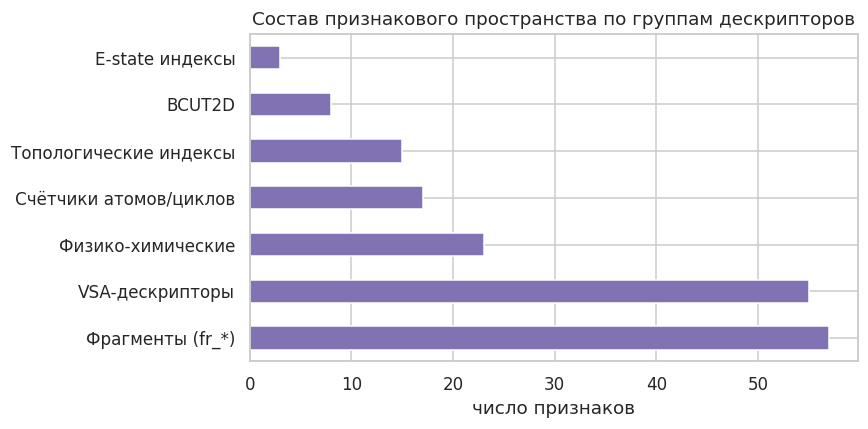

,кол-во
Фрагменты (fr_*),57
VSA-дескрипторы,55
Физико-химические,23
Счётчики атомов/циклов,17
Топологические индексы,15
BCUT2D,8
E-state индексы,3


In [32]:
def feature_group(col):
    """Отнести дескриптор к смысловой группе."""
    if col.startswith("fr_"):
        return "Фрагменты (fr_*)"
    if "VSA" in col:
        return "VSA-дескрипторы"
    if col.startswith(("Chi", "Kappa")):
        return "Топологические индексы"
    if col.startswith("BCUT2D"):
        return "BCUT2D"
    if "EState" in col:
        return "E-state индексы"
    if col.startswith(("Num", "fr", "Ring", "Heavy")):
        return "Счётчики атомов/циклов"
    return "Физико-химические"


groups = pd.Series({c: feature_group(c) for c in X.columns})
counts = groups.value_counts()
plt.figure(figsize=(8, 4))
counts.plot(kind="barh", color="#8172B3")
plt.xlabel("число признаков")
plt.title("Состав признакового пространства по группам дескрипторов")
save_fig("10_feature_groups")
plt.show()
display(counts.to_frame("кол-во"))

In [33]:
group_signal = pd.DataFrame({
    name: groups.groupby(groups).apply(
        lambda idx, n=name: spearman.loc[idx.index, n].abs().mean())
    for name in log_targets.columns
})
print("Средняя |корреляция Спирмена| признаков группы с таргетом:")
display(group_signal.round(3).sort_values("log_IC50", ascending=False))

Средняя |корреляция Спирмена| признаков группы с таргетом:


,log_IC50,log_CC50,log_SI
Топологические индексы,0.145,0.256,0.047
Счётчики атомов/циклов,0.120,0.146,0.118
BCUT2D,0.099,0.093,0.088
VSA-дескрипторы,0.091,0.081,0.091
E-state индексы,0.086,0.073,0.153
Физико-химические,0.077,0.164,0.094
Фрагменты (fr_*),0.066,0.078,0.056


## 10. Сводные выводы EDA и стратегия моделирования
(красивую табилцу попросил у дипсика сделать , каюсь, зато приятнее для понимания)

### Что установлено

| # | Наблюдение | Следствие для моделирования |
|---|---|---|
| 1 | 1001 объект, 210 признаков, дубликатов строк нет | Соотношение n/p ≈ 4.8 — риск переобучения высок, нужна регуляризация и честная кросс-валидация |
| 2 | Пропуски в 12 колонках у 3 объектов, структурные (заряды Гастайгера) | Медианная импутация внутри пайплайна; удаление объектов не требуется |
| 3 | `SI = CC50 / IC50` выполняется точно | SI-регрессию можно решать двумя путями: напрямую и как разность логарифмов двух моделей — сравнить |
| 4 | Таргеты логнормальны (skew до 18, kurt до 361) | Все регрессии решаем в шкале `log10`; метрики дублируем в исходной шкале |
| 5 | Логарифмирование убирает 90%+ «выбросов» по IQR | Массовое удаление объектов не нужно и вредно — экстремумы это ценные сверхактивные соединения |
| 5а | **135 объектов (13.5%) имеют `IC50 = CC50`, то есть `SI = 1` ровно** — признак цензурированных измерений | Основной источник неустранимой ошибки регрессии SI; объекты сохраняем, но эффект проверяем отдельным экспериментом |
| 5б | **1001 строка описывает лишь 804 уникальных набора дескрипторов**; внутригрупповой разброс `log IC50` = 0.30 при общем 0.94 | Обязательна **групповая** кросс-валидация — случайная завышает R² на 0.01–0.03; ≈10% дисперсии таргета необъяснимы принципиально |
| 6 | 18 константных, 5 дублирующих, 9 почти константных признаков | Удаляем до моделирования — остаётся 178 информативных признаков из 210 |
| 7 | 84 пары признаков с \|r\| > 0.95 | Обязательна регуляризация линейных моделей; интерпретация важностей — с осторожностью |
| 8 | Максимальная \|корреляция\| признака с таргетом ≈ 0.2–0.3 | Линейные модели — только baseline; ставка на ансамбли деревьев; ожидаемое качество умеренное |
| 9 | 95% дисперсии X описывается небольшой долей компонент | Полезен эксперимент с отбором признаков |
| 10 | Классы сбалансированы (50/50), кроме `SI > 8` (35.7%) | Стратифицированная CV; для `SI > 8` — PR-AUC и `class_weight` |

### качество

Качество упирается в 2 потолка :
слабые индивидуальные корреляции (максимум 0.2–0.3) и экспериментальный шум, съедающий около 10% дисперсии таргета. 


### схема действий 

- **Разбивка** Тест  20% данных, режется по группам уникальных молекул (GroupShuffleSplit), чтобы исключить утечку. На обучении 5‑fold групповая кросс-валидация (GroupKFold / StratifiedGroupKFold) для настройки гиперпараметров.
- **Предобработка** Импутация и масштабирование только внутри train-фолда, без подглядывания в тест
- **Модели** Константный baseline, линейные модели с регуляризацией (Ridge, Lasso, ElasticNet), kNN, SVM, Random Forest, Gradient Boosting, LightGBM, XGBoost
- **Настройка** RandomizedSearchCV с фиксированным random_state и общей сеткой для всех задач одного типа
- **Метрики** Регрессия: R^2, RMSE, MAE (в log-шкале) и те же метрики после обратного преобразования. Классификация: ROC-AUC (главная), PR-AUC, accuracy, F1, сбалансированная accuracy
- **Устойчивость** Лучшую модель переобучаем на нескольких сидах - смотрим разброс метрик

In [34]:
X_out, y_out, groups_out, rep_out = du.load_dataset()
out_dir = Path.cwd().parent / "data"
X_out.to_csv(out_dir / "features.csv", index=False)
y_out.assign(group=groups_out).to_csv(out_dir / "targets.csv", index=False)
print(f"Сохранено: features.csv {X_out.shape}, targets.csv {y_out.shape}")
print(f"Удалено признаков: {sum(len(v) for v in rep_out.values())}")
print(f"Групп уникальных молекул: {len(np.unique(groups_out))}")

Сохранено: features.csv (1001, 178), targets.csv (1001, 10)
Удалено признаков: 32
Групп уникальных молекул: 804
